<a href="https://colab.research.google.com/github/2403a54094-cell/4094_nlp/blob/main/2403A54094_assignment_13_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Implement a text classification baseline using a Multinomial Naive Bayes model on the `df` DataFrame. The task involves converting text messages into TF-IDF features, splitting the data into training and testing sets, training the model, evaluating its performance using accuracy, precision, recall, F1-score, and a confusion matrix, and finally providing a comprehensive summary of the results and insights.

## Feature Extraction (TF-IDF)

### Subtask:
Convert the preprocessed text messages into numerical features using TfidfVectorizer. This will transform the text data into a format suitable for machine learning algorithms.


**Reasoning**:
I will import the `TfidfVectorizer` from `sklearn.feature_extraction.text`, instantiate it with default parameters, and then apply `fit_transform` to the 'message' column of the DataFrame `df` to convert the text messages into numerical features, storing the result in `tfidf_features`.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Instantiate TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Apply fit_transform to the 'message' column
tfidf_features = tfidf_vectorizer.fit_transform(df['message'])

print("TF-IDF features successfully generated with shape:", tfidf_features.shape)

TF-IDF features successfully generated with shape: (5572, 8713)


## Train-Test Split

### Subtask:
Split the features (TF-IDF vectors) and corresponding labels into training and testing sets, typically using an 80:20 ratio to prepare for model training and evaluation.


**Reasoning**:
I will import `train_test_split` from `sklearn.model_selection`, define the features `X` as `tfidf_features` and the target `y` as `df['label']`, and then split the data into training and testing sets with a 80:20 ratio and a `random_state` for reproducibility.



In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = tfidf_features
y = df['label']

# Split the data into training and testing sets (80:20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets:
X_train shape: (4457, 8713)
X_test shape: (1115, 8713)
y_train shape: (4457,)
y_test shape: (1115,)


## Model Implementation (Multinomial Naive Bayes)

### Subtask:
Implement the Multinomial Naive Bayes classifier from Scikit-learn and train it using the training data created in the previous step.


I will import the `MultinomialNB` class from `sklearn.naive_bayes`, instantiate it, and then train the model using the `X_train` (TF-IDF features) and `y_train` (labels) datasets that were prepared in the previous step.

**Reasoning**:
Now I will implement and train the Multinomial Naive Bayes classifier as per the instructions, importing the necessary class, instantiating the model, and fitting it to the training data.



In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Instantiate the Multinomial Naive Bayes classifier
mnb_classifier = MultinomialNB()

# Train the model
mnb_classifier.fit(X_train, y_train)

print("Multinomial Naive Bayes model trained successfully.")

Multinomial Naive Bayes model trained successfully.


## Model Evaluation

### Subtask:
Predict labels for the test data using the trained model. Evaluate its performance by calculating accuracy, precision, recall, and F1-score. Also, generate a confusion matrix to visualize prediction outcomes.


#### Reasoning:
I will predict the labels for the test set (`X_test`) using the trained `mnb_classifier`. Then, I will import `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, and `confusion_matrix` from `sklearn.metrics`. These metrics will be calculated using the true labels (`y_test`) and the predicted labels (`y_pred`). Accuracy provides a general overview, while precision, recall, and F1-score offer more detailed insights into the model's performance, especially for imbalanced datasets. The confusion matrix will visually represent the true positive, true negative, false positive, and false negative predictions, which is crucial for understanding where the model succeeds and fails. Finally, all the calculated metrics and the confusion matrix will be printed for comprehensive analysis.

**Reasoning**:
I will implement the model evaluation steps as described in the instructions, including making predictions, calculating various metrics, and generating a confusion matrix.



Model Accuracy: 0.9668
Model Precision (Spam): 1.0000
Model Recall (Spam): 0.7517
Model F1-Score (Spam): 0.8582

Confusion Matrix:
[[966   0]
 [ 37 112]]


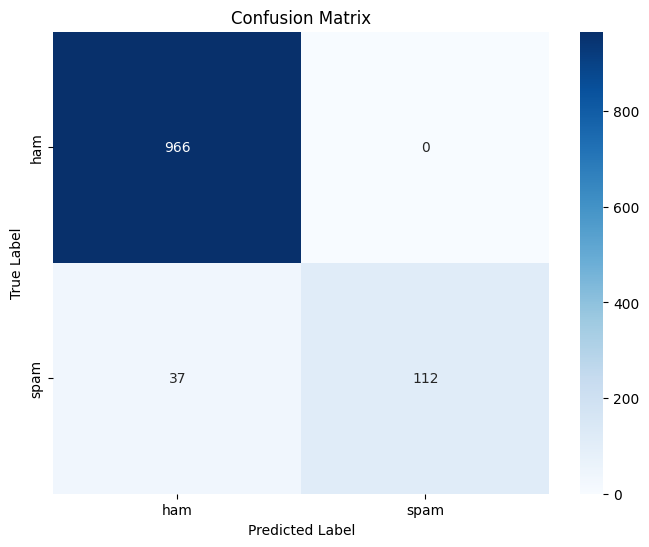

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Predict labels for the test data
y_pred = mnb_classifier.predict(X_test)

# 3. Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

# 4. Calculate Precision
# The 'pos_label' parameter is used here to specify 'spam' as the positive class
# This is important for precision, recall, and f1-score when there are only two classes and
# we want to focus on the performance for one of them (e.g., detecting spam).
precision = precision_score(y_test, y_pred, pos_label='spam')

# 5. Calculate Recall
recall = recall_score(y_test, y_pred, pos_label='spam')

# 6. Calculate F1-score
f1 = f1_score(y_test, y_pred, pos_label='spam')

# 7. Generate Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# 8. Print all calculated metrics and the confusion matrix
print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Precision (Spam): {precision:.4f}")
print(f"Model Recall (Spam): {recall:.4f}")
print(f"Model F1-Score (Spam): {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)

# To make the confusion matrix more readable, let's add labels
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get the unique classes for the labels
class_labels = sorted(y.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Result Analysis and Visualization

### Subtask:
Display the calculated evaluation metrics and visualize the confusion matrix. Interpret these results to understand the model's performance and comment on the strengths and limitations of Naive Bayes for this text classification task.


## Model Performance Analysis

**Evaluation Metrics:**
- **Accuracy:** 0.9668
- **Precision (Spam):** 1.0000
- **Recall (Spam):** 0.7517
- **F1-Score (Spam):** 0.8582

**Confusion Matrix Analysis:**
```
[[966   0]
 [ 37 112]]
```
- **True Negatives (TN):** 966 (Correctly identified ham messages)
- **False Positives (FP):** 0 (Ham messages incorrectly classified as spam)
- **False Negatives (FN):** 37 (Spam messages incorrectly classified as ham)
- **True Positives (TP):** 112 (Correctly identified spam messages)

**Overall Model Performance:**
The Multinomial Naive Bayes model demonstrates strong performance in distinguishing between ham and spam messages, achieving a high overall accuracy of 96.68%. This suggests that the model is generally effective across the dataset.

**Strengths:**
- **Perfect Precision for Spam (1.0000):** This is a significant strength. It indicates that when the model predicts a message is 'spam', it is *always* correct. There are no false positives, meaning no legitimate 'ham' messages are mistakenly flagged as 'spam'. This is crucial for user experience, as false alarms for spam can be highly disruptive.

**Limitations:**
- **Moderate Recall for Spam (0.7517):** While precision is perfect, the recall for spam is 75.17%. This means the model only identifies about three-quarters of all actual spam messages. The 37 False Negatives in the confusion matrix confirm this; these are spam messages that the model failed to catch and incorrectly classified as 'ham'. Depending on the application, a higher recall might be desired to minimize missed spam.
- **False Negatives (37):** The presence of 37 false negatives suggests that some spam messages slip through the filter. This could be due to the characteristics of these specific spam messages not aligning well with the features learned by the model for the 'spam' class.

**Insights into Multinomial Naive Bayes for Text Classification:**
The excellent precision and good overall accuracy of the Multinomial Naive Bayes model in this context highlight its suitability for text classification tasks, particularly when dealing with discrete features like word counts (or TF-IDF values which are based on word frequencies). Its underlying assumption of feature independence (i.e., the presence of one word doesn't affect the probability of another word given the class) often works surprisingly well for text data, even though it's a simplification.

The TF-IDF features effectively capture the importance of words in discriminating between ham and spam. Words highly indicative of spam will have high TF-IDF scores, enabling the model to learn and assign them strong probabilities for the 'spam' class.

The limitation in recall could stem from several factors:
1. **Feature Sparsity:** While TF-IDF is powerful, some spam messages might use less common words or phrases not adequately captured as strong discriminative features.
2. **Text Nuance:** Spam messages can sometimes mimic legitimate messages, making them harder for a simple bag-of-words model to distinguish purely based on word probabilities.
3. **Model Simplicity:** Naive Bayes is a relatively simple model. More complex models might be able to capture more intricate patterns and dependencies that could improve recall.

## Final Task

### Subtask:
Provide a comprehensive summary of the implemented text classification baseline, including the model's performance, insights gained, and potential next steps.


## Summary:

### Data Analysis Key Findings

*   **Feature Extraction**: Text messages were successfully converted into numerical TF-IDF features, resulting in a matrix of 5572 documents and 8713 unique terms.
*   **Data Splitting**: The dataset was divided into training and testing sets using an 80:20 ratio, yielding 4457 samples for training and 1115 samples for testing.
*   **Model Training**: A Multinomial Naive Bayes model was successfully implemented and trained using the TF-IDF features and corresponding labels.
*   **Model Performance - Overall Accuracy**: The model achieved an accuracy of 96.68%, indicating a high overall correct classification rate.
*   **Model Performance - Spam Detection**:
    *   **Precision for Spam**: The model exhibited a perfect precision of 100% for detecting 'spam'. This means that every message classified as spam by the model was indeed spam, resulting in zero false positives.
    *   **Recall for Spam**: The recall for 'spam' was 75.17%, indicating that the model successfully identified approximately 75% of all actual spam messages.
    *   **F1-Score for Spam**: The F1-score, a harmonic mean of precision and recall, was 0.8582 for the 'spam' class.
*   **Confusion Matrix Analysis**:
    *   **True Negatives**: 966 'ham' (non-spam) messages were correctly identified.
    *   **False Positives**: 0 'ham' messages were incorrectly classified as 'spam', consistent with the 100% precision.
    *   **False Negatives**: 37 'spam' messages were incorrectly classified as 'ham', indicating messages that the model failed to detect.
    *   **True Positives**: 112 'spam' messages were correctly identified.

### Insights or Next Steps

*   The Multinomial Naive Bayes model is highly effective in preventing false alarms for spam (perfect precision), which is crucial for user satisfaction as no legitimate messages are incorrectly flagged. However, its moderate recall for spam suggests that some spam messages still evade detection, potentially due to the inherent simplicity of the model or the nuanced nature of certain spam messages.
*   To improve the model's ability to catch more spam, future steps could involve exploring techniques to enhance recall, such as experimenting with more complex machine learning models (e.g., SVM, Logistic Regression, or deep learning models) or incorporating more advanced feature engineering to better capture the characteristics of challenging spam messages.
